In [2]:
from pathlib import Path 

import cv2 
import numpy as np
import IPython

In [3]:
def draw_faces(image, faces, draw_landmarks):
    for face in faces:
        # バウンディングボックス
        box = list(map(int, face[:4]))
        color = (0, 0, 255)
        thickness = 2
        cv2.rectangle(image, box, color, thickness, cv2.LINE_AA)

        if draw_landmarks:
            # ランドマーク（右目、左目、鼻、右口角、左口角）
            landmarks = list(map(int, face[4:len(face)-1]))
            landmarks = np.array_split(landmarks, len(landmarks) / 2)
            for landmark in landmarks:
                radius = 5
                thickness = -1
                cv2.circle(image, landmark, radius, color, thickness, cv2.LINE_AA)
            
        # 信頼度
        confidence = face[-1]
        confidence = "{:.2f}".format(confidence)
        position = (box[0], box[1] - 10)
        font = cv2.FONT_HERSHEY_SIMPLEX
        scale = 0.5
        thickness = 2
        cv2.putText(image, confidence, position, font, scale, color, thickness, cv2.LINE_AA)

In [23]:
def show_image(image):
    _, ret = cv2.imencode('.jpg', image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)

In [25]:
def show_faces(image, faces, draw_landmarks=True):
    draw_faces(image, faces, draw_landmarks=draw_landmarks)
    show_image(image)

In [81]:
cap = cv2.VideoCapture('/home/amos/test.mkv')
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)


True

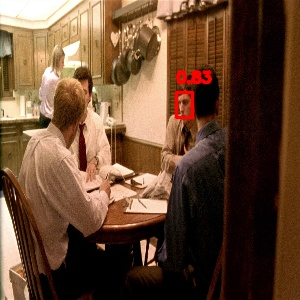

49752


In [85]:
cnt = 0
_, _ = cap.read()
while True:
    if cnt % 24 == 0:
        _, frame = cap.read()
        # if frame is None: 
        #     continue 
        size = 300
        weights = Path('..').joinpath('opencv_zoo/models/face_detection_yunet/face_detection_yunet_2023mar.onnx')
        fd = cv2.FaceDetectorYN_create(str(weights), "", (size, size), score_threshold=0.75)
        # frame = cv2.imread('./images/img_1.jpg')
        img = cv2.cvtColor(frame, cv2.COLOR_BGRA2BGR)
        img = cv2.resize(img, (size, size))
        fd.setInputSize((size, size))
        result = fd.detect(img)
        if result[1] is None:
            cnt += 1
            continue
        faces = [x for x in result[1]]
        show_faces(img, faces, draw_landmarks=False)
        break
    cnt = cnt + 1
print(cnt)

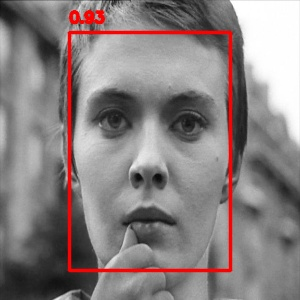

In [17]:
image = cv2.imread('./images/img_1.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGRA2BGR)
image = cv2.resize(image, (size, size))
result = fd.detect(image)
faces = [x for x in result[1]]
show_faces(image, faces, draw_landmarks=False)

In [18]:
box = list(map(int, faces[0][:4]))
box

[69, 32, 162, 239]

[h264 @ 0x240bec0] mmco: unref short failure


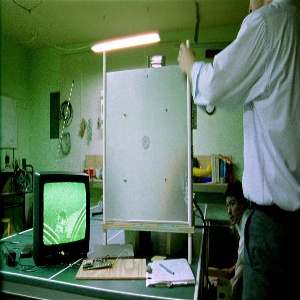

In [61]:
fd = cv2.FaceDetectorYN_create(str(weights), "", (size, size), score_threshold=0.5)
cap.set(cv2.CAP_PROP_POS_FRAMES, 18960)
_, frame = cap.read()
image = cv2.cvtColor(frame, cv2.COLOR_BGRA2BGR)
image = cv2.resize(image, (size, size))
show_image(image)

In [60]:
result = fd.detect(image)
faces = [x for x in result[1]]
color = (0, 0, 255)
thickness = 2
box = list(map(int, faces[0][:4]))
x1, y1, x2, y2 = box 
cv2.rectangle(image, (x1, y1), (x1 + x2, y1 + y2), color, thickness, cv2.LINE_AA)
show_image(image)

TypeError: 'NoneType' object is not iterable

[h264 @ 0x1f98180] mmco: unref short failure


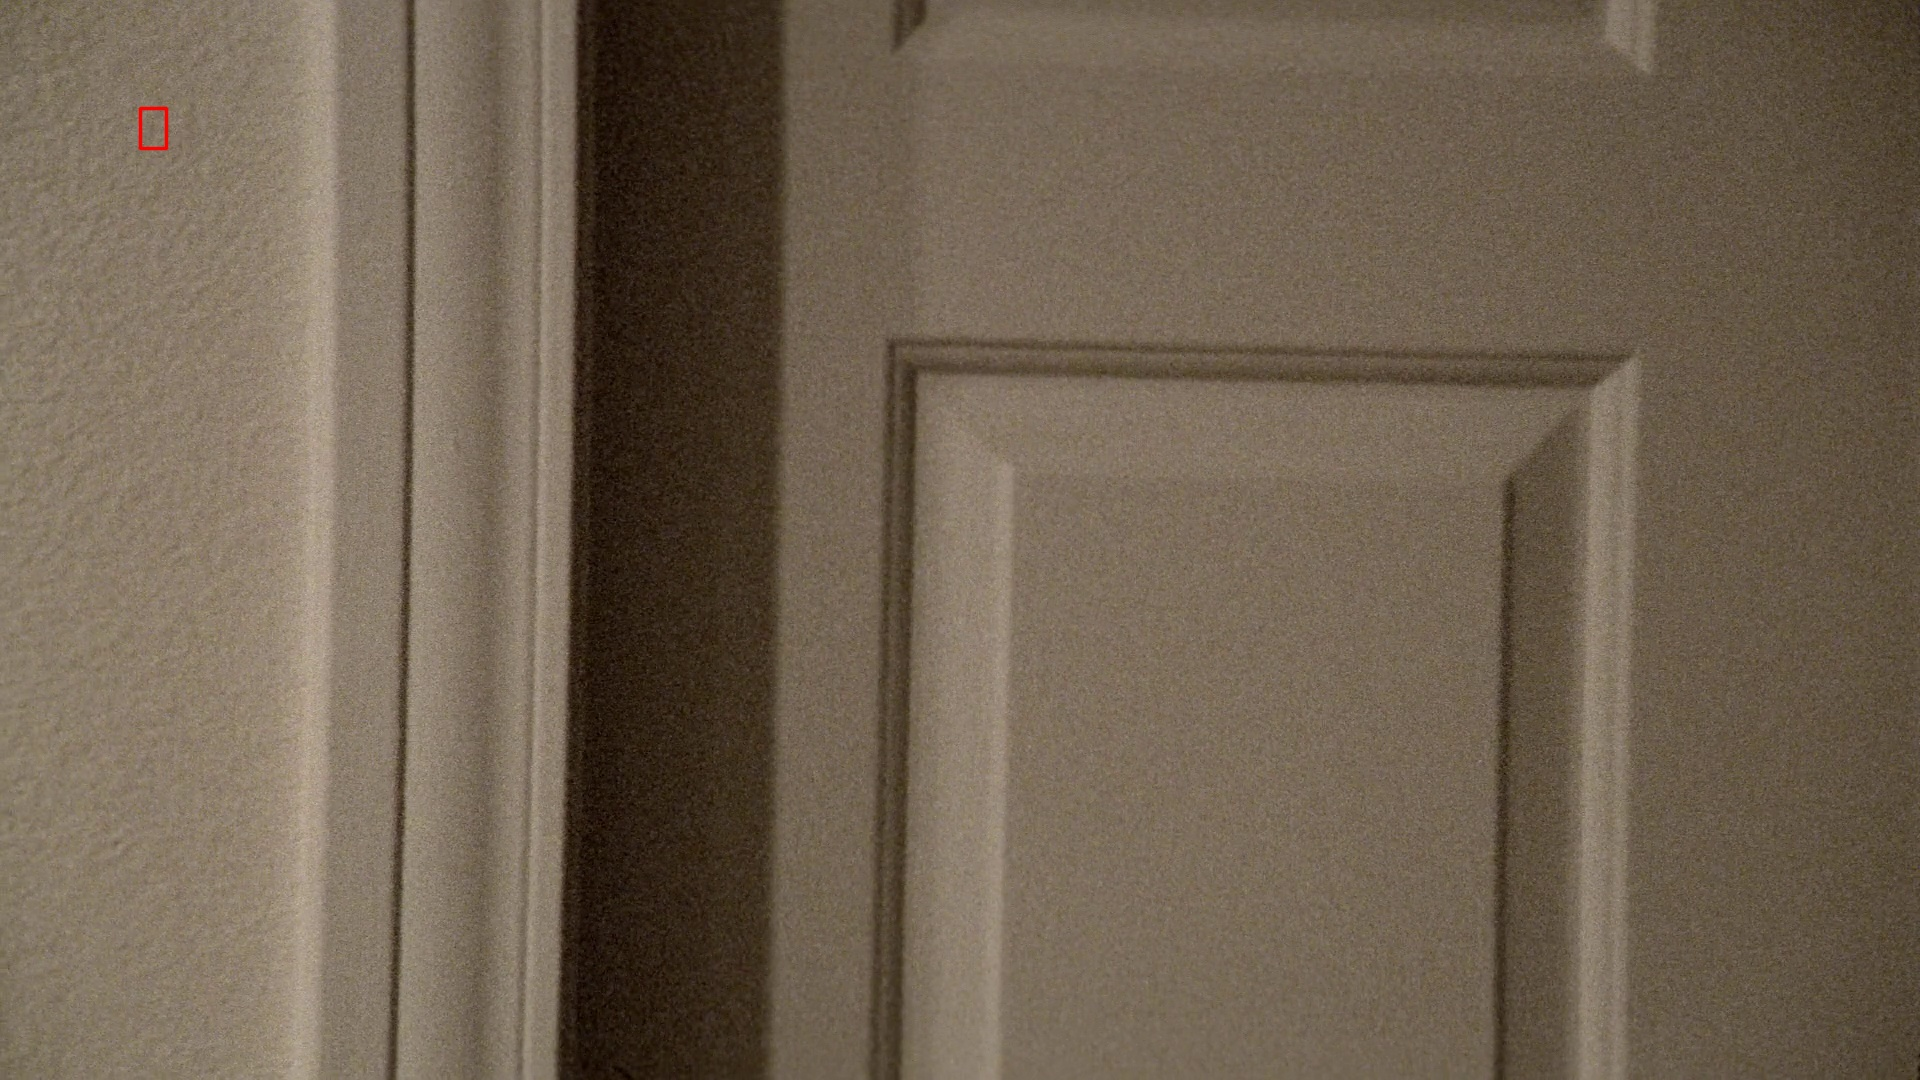

In [52]:
cap.set(cv2.CAP_PROP_POS_FRAMES, 89832)
_, frame = cap.read()
image = cv2.cvtColor(frame, cv2.COLOR_BGRA2BGR)
# image = cv2.resize(image, (size, size))
cv2.rectangle(image, (140, 108), (166, 148), color, thickness, cv2.LINE_AA)
show_image(image)

In [ ]:
# (x1, x2), (y1, y2)
# (x1, y1), (x2, y2)
# (y1, x1), (y2, x2)
# (x2, y2), (x1, y1)
# ()

In [37]:
box 

[217, 58, 14, 20]

In [14]:
h, w = frame.shape[:2]
x1, y1, x2, y2 = list(map(int, faces[0][:4]))
print(x1, y1, x2, y2)

176 92 17 26


In [15]:
a = np.array([(x1, y1), (x2, y2)])
a

array([[176,  92],
       [ 17,  26]])

In [16]:
xv = np.array([w/size, h/size])
xv

array([6.4, 3.6])

In [17]:
c = a * xv 
c

array([[1126.4,  331.2],
       [ 108.8,   93.6]])

In [28]:
(x1_s, y1_s), (x2_s, y2_s) = c.tolist()
print(x1_s, y1_s, x2_s, y2_s)

1126.4 331.2 108.80000000000001 93.60000000000001


In [19]:
ih, iw = frame.shape[:2]
rw, rh = (300, 300)
a = np.array([
        (x1, y1),
        (x2, y2)
            ])
b = np.array([iw/rw, ih/rh])
(x1_s, x2_s), (y1_s, y2_s) = (a * b).tolist()

In [20]:
a

array([[176,  92],
       [ 17,  26]])

In [21]:
b

array([6.4, 3.6])

In [25]:
a * b

array([[1126.4,  331.2],
       [ 108.8,   93.6]])

In [26]:
print(x1, y1, x2, y2)

176 92 17 26


In [24]:
(x1_s, x2_s), (y1_s, y2_s) = (a * b).tolist()
print(x1_s, y1_s, x2_s, y2_s)

1126.4 108.80000000000001 331.2 93.60000000000001


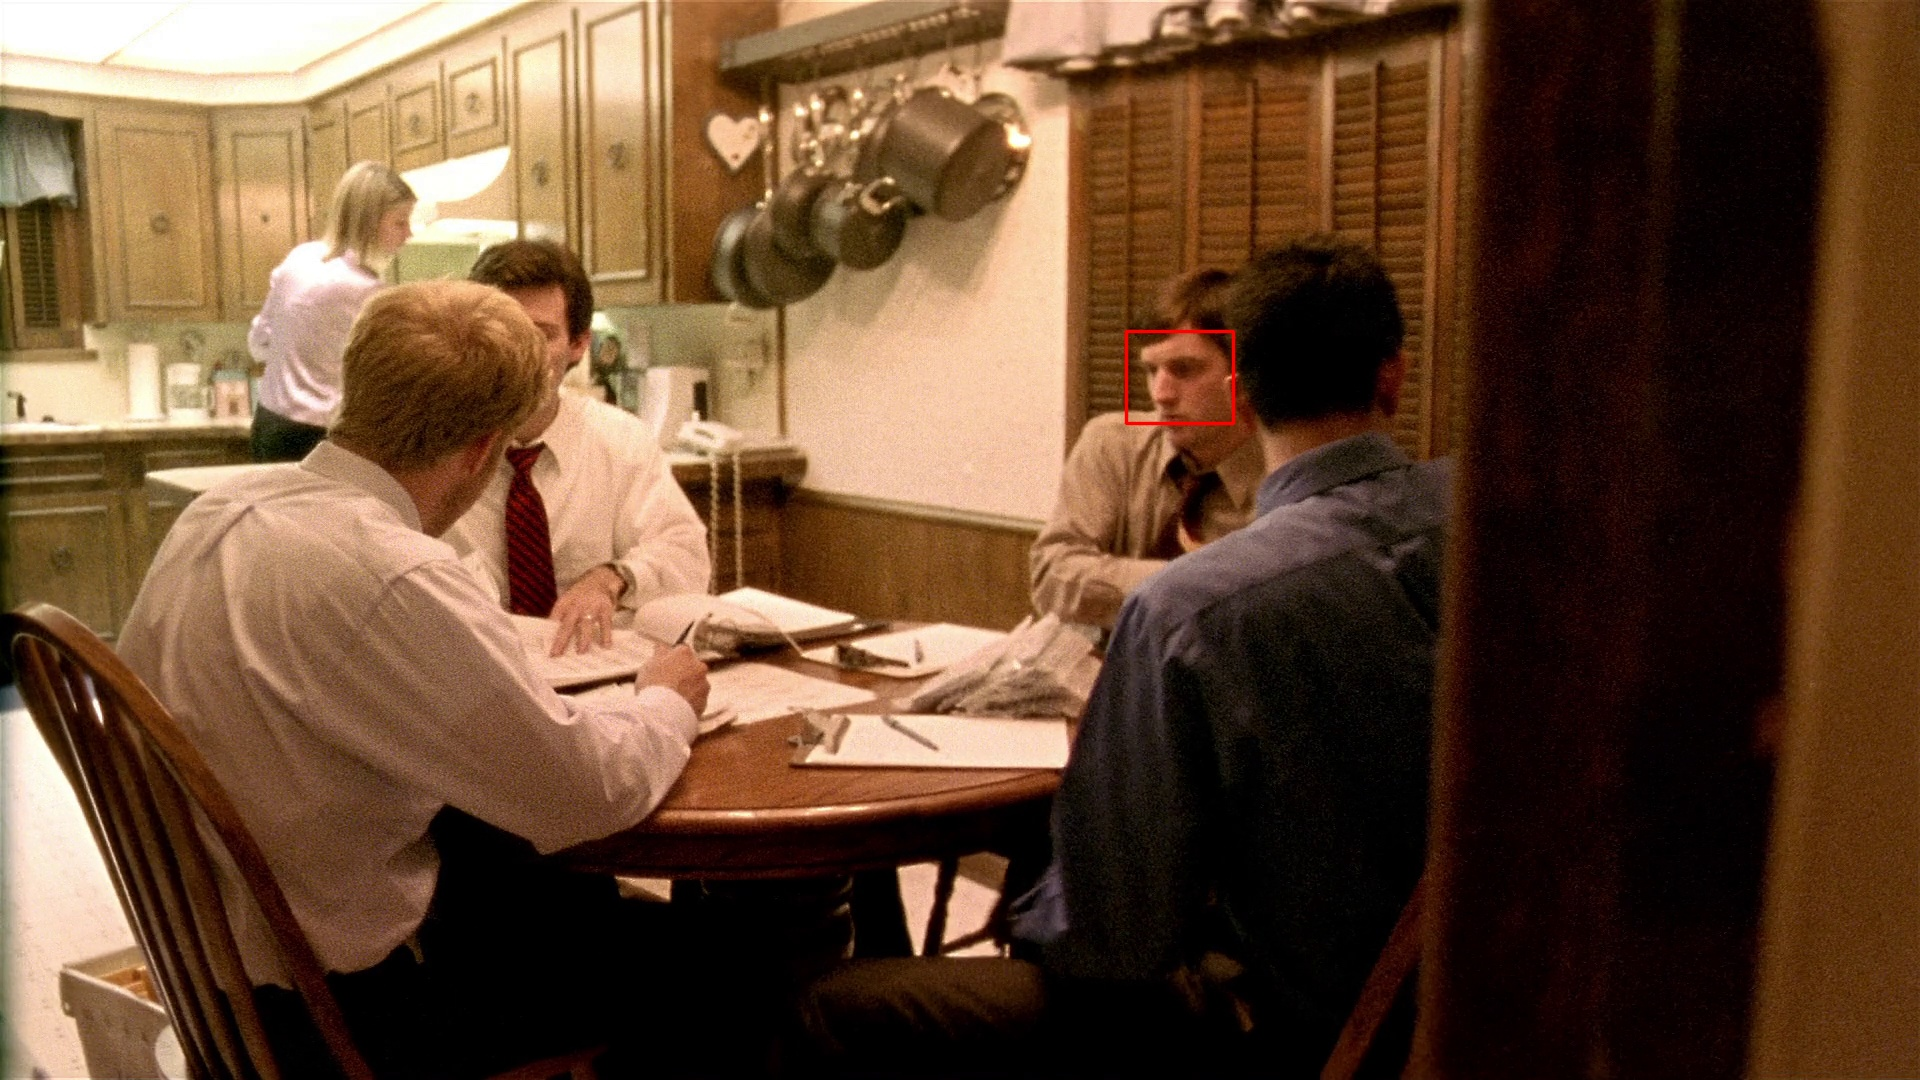

In [29]:
cv2.rectangle(frame, [int(x1_s), int(y1_s), int(x2_s), int(y2_s)], (0, 0, 255), 2, cv2.LINE_AA)
_, ret = cv2.imencode('.jpg', frame)
i = IPython.display.Image(data=ret)
IPython.display.display(i)

In [57]:
face = result[1][0]
landmarks = list(map(int, face[4:len(face)-1]))
landmarks = np.array_split(landmarks, len(landmarks) / 2)
landmarks

TypeError: 'NoneType' object is not subscriptable

In [23]:
positions = ['left_eye', 'right_eye', 'nose', 'right_mouth', 'left_mouth']
d = {positions[num]: x.tolist() for num, x in enumerate(landmarks)}
d

{'left_eye': [109, 124],
 'right_eye': [186, 126],
 'nose': [144, 173],
 'right_mouth': [116, 210],
 'left_mouth': [178, 211]}

In [29]:
# 0 = Left Eye (from viewer's perspective)
# 1 = Right Eye
# 2 = Nose
# 3 = Left Mouth
# 4 = Rigth Mouth

for landmark in landmarks:
                radius = 5
                thickness = -1
                cv2.circle(img, landmark, radius, (0, 0, 255), thickness, cv2.LINE_AA)

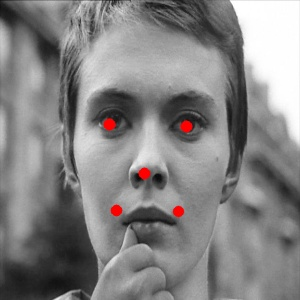

In [30]:
_, ret = cv2.imencode('.jpg', img)
i = IPython.display.Image(data=ret)
IPython.display.display(i)

In [51]:
from importlib import reload
import Detectors
reload(Detectors)

<module 'Detectors' from '/home/amos/programs/videotools/videotools/Detectors.py'>

In [52]:
yunet = Detectors.FaceDetectorYunet()

In [53]:
yunet.predict_image(img)

<class 'tuple'>


TypeError: cannot unpack non-iterable int object